# Deep Learning Project 6
## Recurrent Sequence to Sequence Model for Natural Language Processing

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

# Fix the seeds so results are reproducible across runs
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Set the Hyperparameters

In [ ]:
# Mount Google Drive to access the dataset and save the trained model
drive.mount('/content/drive')

# Set the batch size — number of sentence pairs processed per gradient update
BATCH_SIZE = 64
# Set the number of training epochs — how many full passes through the data
EPOCHS = 100
# Latent dimensionality of the encoding space — size of the LSTM hidden state vectors
LATENT_DIM = 256
# Number of sentence pairs to use from the dataset
NUM_SAMPLES = 10000
# Path to the dataset on Google Drive
DATA_PATH = '/content/drive/MyDrive/DSCI_619_Datasets/deu-eng.txt'
# Path to save the trained model on Google Drive
SAVE_DIR = '/content/drive/MyDrive/DSCI_619_Datasets'
MODEL_PATH = f'{SAVE_DIR}/s2s_deu.keras'

# Create the save directory if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load and Prepare the Data

In [ ]:
# Storage for input (English) and target (German) sentence pairs
input_texts = []
target_texts = []
# Unique characters in the inputs and targets
input_characters = set()
target_characters = set()

# Load the data into memory
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    lines = f.read().split('\n')

# Process line by line
for line in lines[:min(NUM_SAMPLES, len(lines) - 1)]:
    # Data format: English + TAB + German + TAB + Attribution
    # Split on tab and discard the attribution (the third field)
    input_text, target_text, _ = line.split('\t')
    # We use "tab" as the start sequence character
    # for the targets, and \n as the end sequence character
    target_text = '\t' + target_text + '\n'
    input_texts.append(input_text)
    target_texts.append(target_text)
    # Get the unique char from the English input texts
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)
    # Get the unique characters from the German target
    # German has extra characters (ä, ö, ü, ß) not in English
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)

### Sort Input Characters and Output Characters

In [ ]:
input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))
# Count unique characters in each language — determines the third dimension of our 3D matrices
num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)
# Find the longest sentence in each language — determines the second dimension of our 3D matrices
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

print(f'Number of samples:= {len(input_texts)}')
print(f'Number of unique input tokens: = {num_encoder_tokens}')
print(f'Number of unique output tokens: = {num_decoder_tokens}')
print(f'Max sequence length for inputs: = {max_encoder_seq_length}')
print(f'Max sequence length for outputs: = {max_decoder_seq_length}')

Number of samples:= 10000
Number of unique input tokens: = 71
Number of unique output tokens: = 85
Max sequence length for inputs: = 15
Max sequence length for outputs: = 45


### Map Characters to Numbers

In [ ]:
# Map each character to a unique integer index
# The key is the character, the value is its index
input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

In [ ]:
# Preview the English character-to-index mapping
input_token_index

{' ': 0,
 '!': 1,
 '"': 2,
 '$': 3,
 '%': 4,
 "'": 5,
 ',': 6,
 '-': 7,
 '.': 8,
 '0': 9,
 '1': 10,
 '2': 11,
 '3': 12,
 '4': 13,
 '5': 14,
 '6': 15,
 '7': 16,
 '8': 17,
 '9': 18,
 ':': 19,
 '?': 20,
 'A': 21,
 'B': 22,
 'C': 23,
 'D': 24,
 'E': 25,
 'F': 26,
 'G': 27,
 'H': 28,
 'I': 29,
 'J': 30,
 'K': 31,
 'L': 32,
 'M': 33,
 'N': 34,
 'O': 35,
 'P': 36,
 'Q': 37,
 'R': 38,
 'S': 39,
 'T': 40,
 'U': 41,
 'V': 42,
 'W': 43,
 'Y': 44,
 'a': 45,
 'b': 46,
 'c': 47,
 'd': 48,
 'e': 49,
 'f': 50,
 'g': 51,
 'h': 52,
 'i': 53,
 'j': 54,
 'k': 55,
 'l': 56,
 'm': 57,
 'n': 58,
 'o': 59,
 'p': 60,
 'q': 61,
 'r': 62,
 's': 63,
 't': 64,
 'u': 65,
 'v': 66,
 'w': 67,
 'x': 68,
 'y': 69,
 'z': 70}

In [ ]:
# Preview the German character-to-index mapping
target_token_index

{'\t': 0,
 '\n': 1,
 ' ': 2,
 '!': 3,
 '$': 4,
 '%': 5,
 "'": 6,
 ',': 7,
 '-': 8,
 '.': 9,
 '0': 10,
 '1': 11,
 '2': 12,
 '3': 13,
 '4': 14,
 '5': 15,
 '6': 16,
 '7': 17,
 '8': 18,
 '9': 19,
 ':': 20,
 '?': 21,
 'A': 22,
 'B': 23,
 'C': 24,
 'D': 25,
 'E': 26,
 'F': 27,
 'G': 28,
 'H': 29,
 'I': 30,
 'J': 31,
 'K': 32,
 'L': 33,
 'M': 34,
 'N': 35,
 'O': 36,
 'P': 37,
 'Q': 38,
 'R': 39,
 'S': 40,
 'T': 41,
 'U': 42,
 'V': 43,
 'W': 44,
 'Y': 45,
 'Z': 46,
 'a': 47,
 'b': 48,
 'c': 49,
 'd': 50,
 'e': 51,
 'f': 52,
 'g': 53,
 'h': 54,
 'i': 55,
 'j': 56,
 'k': 57,
 'l': 58,
 'm': 59,
 'n': 60,
 'o': 61,
 'p': 62,
 'q': 63,
 'r': 64,
 's': 65,
 't': 66,
 'u': 67,
 'v': 68,
 'w': 69,
 'x': 70,
 'y': 71,
 'z': 72,
 '\xa0': 73,
 'Ä': 74,
 'Ö': 75,
 'Ü': 76,
 'ß': 77,
 'ä': 78,
 'ö': 79,
 'ü': 80,
 '’': 81,
 '“': 82,
 '„': 83,
 '\u202f': 84}

### Convert Input and Target Texts to Numerical Values

In [ ]:
# Initialize the 3D matrices with all zeros
# Shape: (num_samples, max_sequence_length, num_unique_characters)
encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype='float32'
)
decoder_input_data = np.zeros(
   (len(target_texts), max_decoder_seq_length, num_decoder_tokens), dtype='float32'
)
# decoder_target_data is decoder_input_data offset by one timestep
# it does not include the start character \t
decoder_target_data = np.zeros(
    (len(target_texts), max_decoder_seq_length, num_decoder_tokens), dtype='float32'
)
# Fill in the 1s for each character at each position in each sentence
for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    # Encode each English character as a one-hot vector
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0
        # Pad remaining positions with space character so all sequences are the same length
        encoder_input_data[i, t + 1:, input_token_index[' ']] = 1.0

    # Encode each German character as a one-hot vector
    for t, char in enumerate(target_text):
        # decoder_input starts with \t and includes all characters
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target is ahead of decoder_input by one timestep
            # and does not include the start character \t
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0
    # Pad remaining positions with space character
    decoder_input_data[i, t + 1:, target_token_index[' ']] = 1.0
    decoder_target_data[i, t:, target_token_index[' ']] = 1.0

### Preview the 3D matrices

In [ ]:
encoder_input_data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0.

In [ ]:
decoder_input_data

array([[[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       ...,

       [[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0.

In [ ]:
decoder_target_data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0.

### Build the Seq2Seq Model

In [ ]:
def build_model(num_encoder_tokens, num_decoder_tokens, latent_dim):
    ## Begin Define the encoder layers
    # Define an input sequence
    encoder_inputs = keras.Input(shape=(None, num_encoder_tokens))
    # Define the LSTM which will return the hidden states
    encoder = keras.layers.LSTM(latent_dim, return_state=True)
    # Apply LSTM and return the outputs and hidden states
    encoder_outputs, state_h, state_c = encoder(encoder_inputs)
    # Discard the outputs and only keep the states
    # The states carry the context (meaning) of the English sentence
    encoder_states = [state_h, state_c]
    ## End Define the encoder layers

    ## Begin Define the decoder layers
    # Define the decoder inputs — receives German characters one at a time during training
    decoder_inputs = keras.Input(shape=(None, num_decoder_tokens))
    decoder_lstm = keras.layers.LSTM(latent_dim, return_sequences=True, return_state=True)
    # Set up the decoder using encoder_states as initial state
    # This is how the decoder receives context about what to translate
    # Keep the outputs and discard the hidden states during training
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
    # Forecast the decoder outputs using a classifier based on the decoder outputs
    decoder_dense = keras.layers.Dense(num_decoder_tokens, activation='softmax')
    decoder_outputs = decoder_dense(decoder_outputs)
    ## End Define the decoder layers

    # Define the model that will turn
    # encoder_input_data and decoder_input_data into decoder_target_data
    model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
    return model


model = build_model(num_encoder_tokens, num_decoder_tokens, LATENT_DIM)

### Configure the Model

In [ ]:
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 71)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None, 85)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    335,872 │ input_layer[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    350,208 │ input_layer_1[0]… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 85)  │     21,845 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 707,925 (2.70 MB)

 Trainable params: 707,925 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [ ]:
if os.path.exists(MODEL_PATH):
    # Load the previously trained model from Drive — skips retraining
    print("Found saved model — loading from Drive...")
    model = keras.models.load_model(MODEL_PATH)
    # Load training history so we can still plot the loss curves
    train_history = pd.read_csv(f'{SAVE_DIR}/s2s_deu_history.csv')
    print("Model loaded successfully!")
else:
    print("No saved model found — training from scratch...")
    # Stop training early if val_accuracy stops improving
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        min_delta=0.001,
        mode='max'
    )
    history = model.fit(
        [encoder_input_data, decoder_input_data],
        decoder_target_data,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.2,
        callbacks=[early_stopping]
    )
    # Save the trained model to Drive so we don't have to retrain next session
    model.save(MODEL_PATH)
    # Save training history as CSV so we can plot it on future loads
    train_history = pd.DataFrame(history.history)
    train_history['epoch'] = history.epoch
    train_history.to_csv(f'{SAVE_DIR}/s2s_deu_history.csv', index=False)
    print("Model and history saved to Drive!")

No saved model found — training from scratch...
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 299ms/step - accuracy: 0.6380 - loss: 1.5549 - val_accuracy: 0.6051 - val_loss: 1.6204
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 313ms/step - accuracy: 0.6681 - loss: 1.2036 - val_accuracy: 0.6448 - val_loss: 1.2646
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 306ms/step - accuracy: 0.7206 - loss: 1.0358 - val_accuracy: 0.7122 - val_loss: 1.0649
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 288ms/step - accuracy: 0.7507 - loss: 0.9006 - val_accuracy: 0.7219 - val_loss: 0.9892
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 290ms/step - accuracy: 0.7676 - loss: 0.8236 - val_accuracy: 0.7416 - val_loss: 0.9078
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 315ms/step - accuracy: 0.7794 - loss: 0.7727 - val_accuracy: 0.7571 - val_loss: 0.8579
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 291ms/step - accuracy: 0.7890 - loss: 0.7363 - val_accuracy: 0.7635 - val_loss: 0.8366
Epoch 8/100
125/125 ━━━━━━━━

### Model Diagnostics

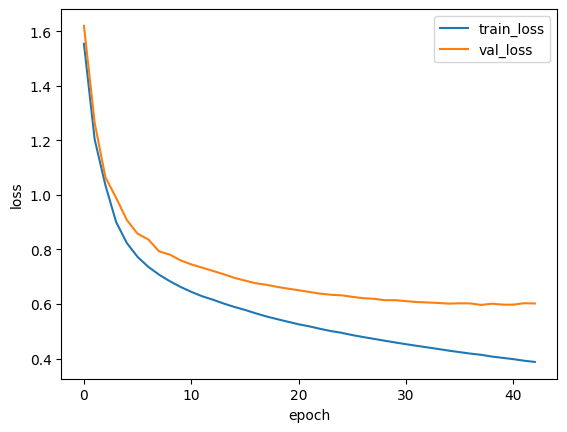

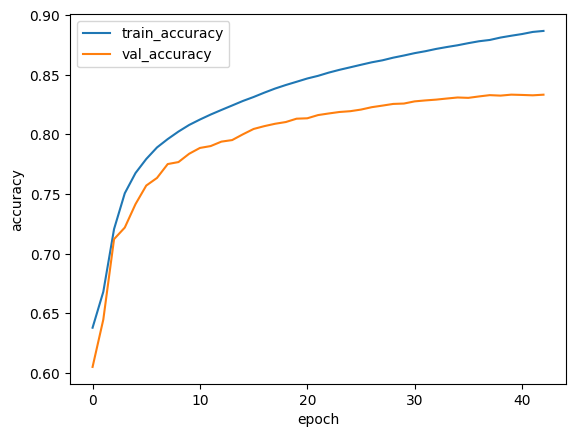

In [ ]:
# Plot train and validation loss
sns.lineplot(x='epoch', y='loss', data=train_history, label='train_loss')
sns.lineplot(x='epoch', y='val_loss', data=train_history, label='val_loss')
plt.legend()
plt.show()

# Plot train and validation accuracy
sns.lineplot(x='epoch', y='accuracy', data=train_history, label='train_accuracy')
sns.lineplot(x='epoch', y='val_accuracy', data=train_history, label='val_accuracy')
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 71)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None, 85)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    335,872 │ input_layer[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    350,208 │ input_layer_1[0]… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 85)  │     21,845 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,415,852 (5.40 MB)

 Trainable params: 707,925 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 707,927 (2.70 MB)

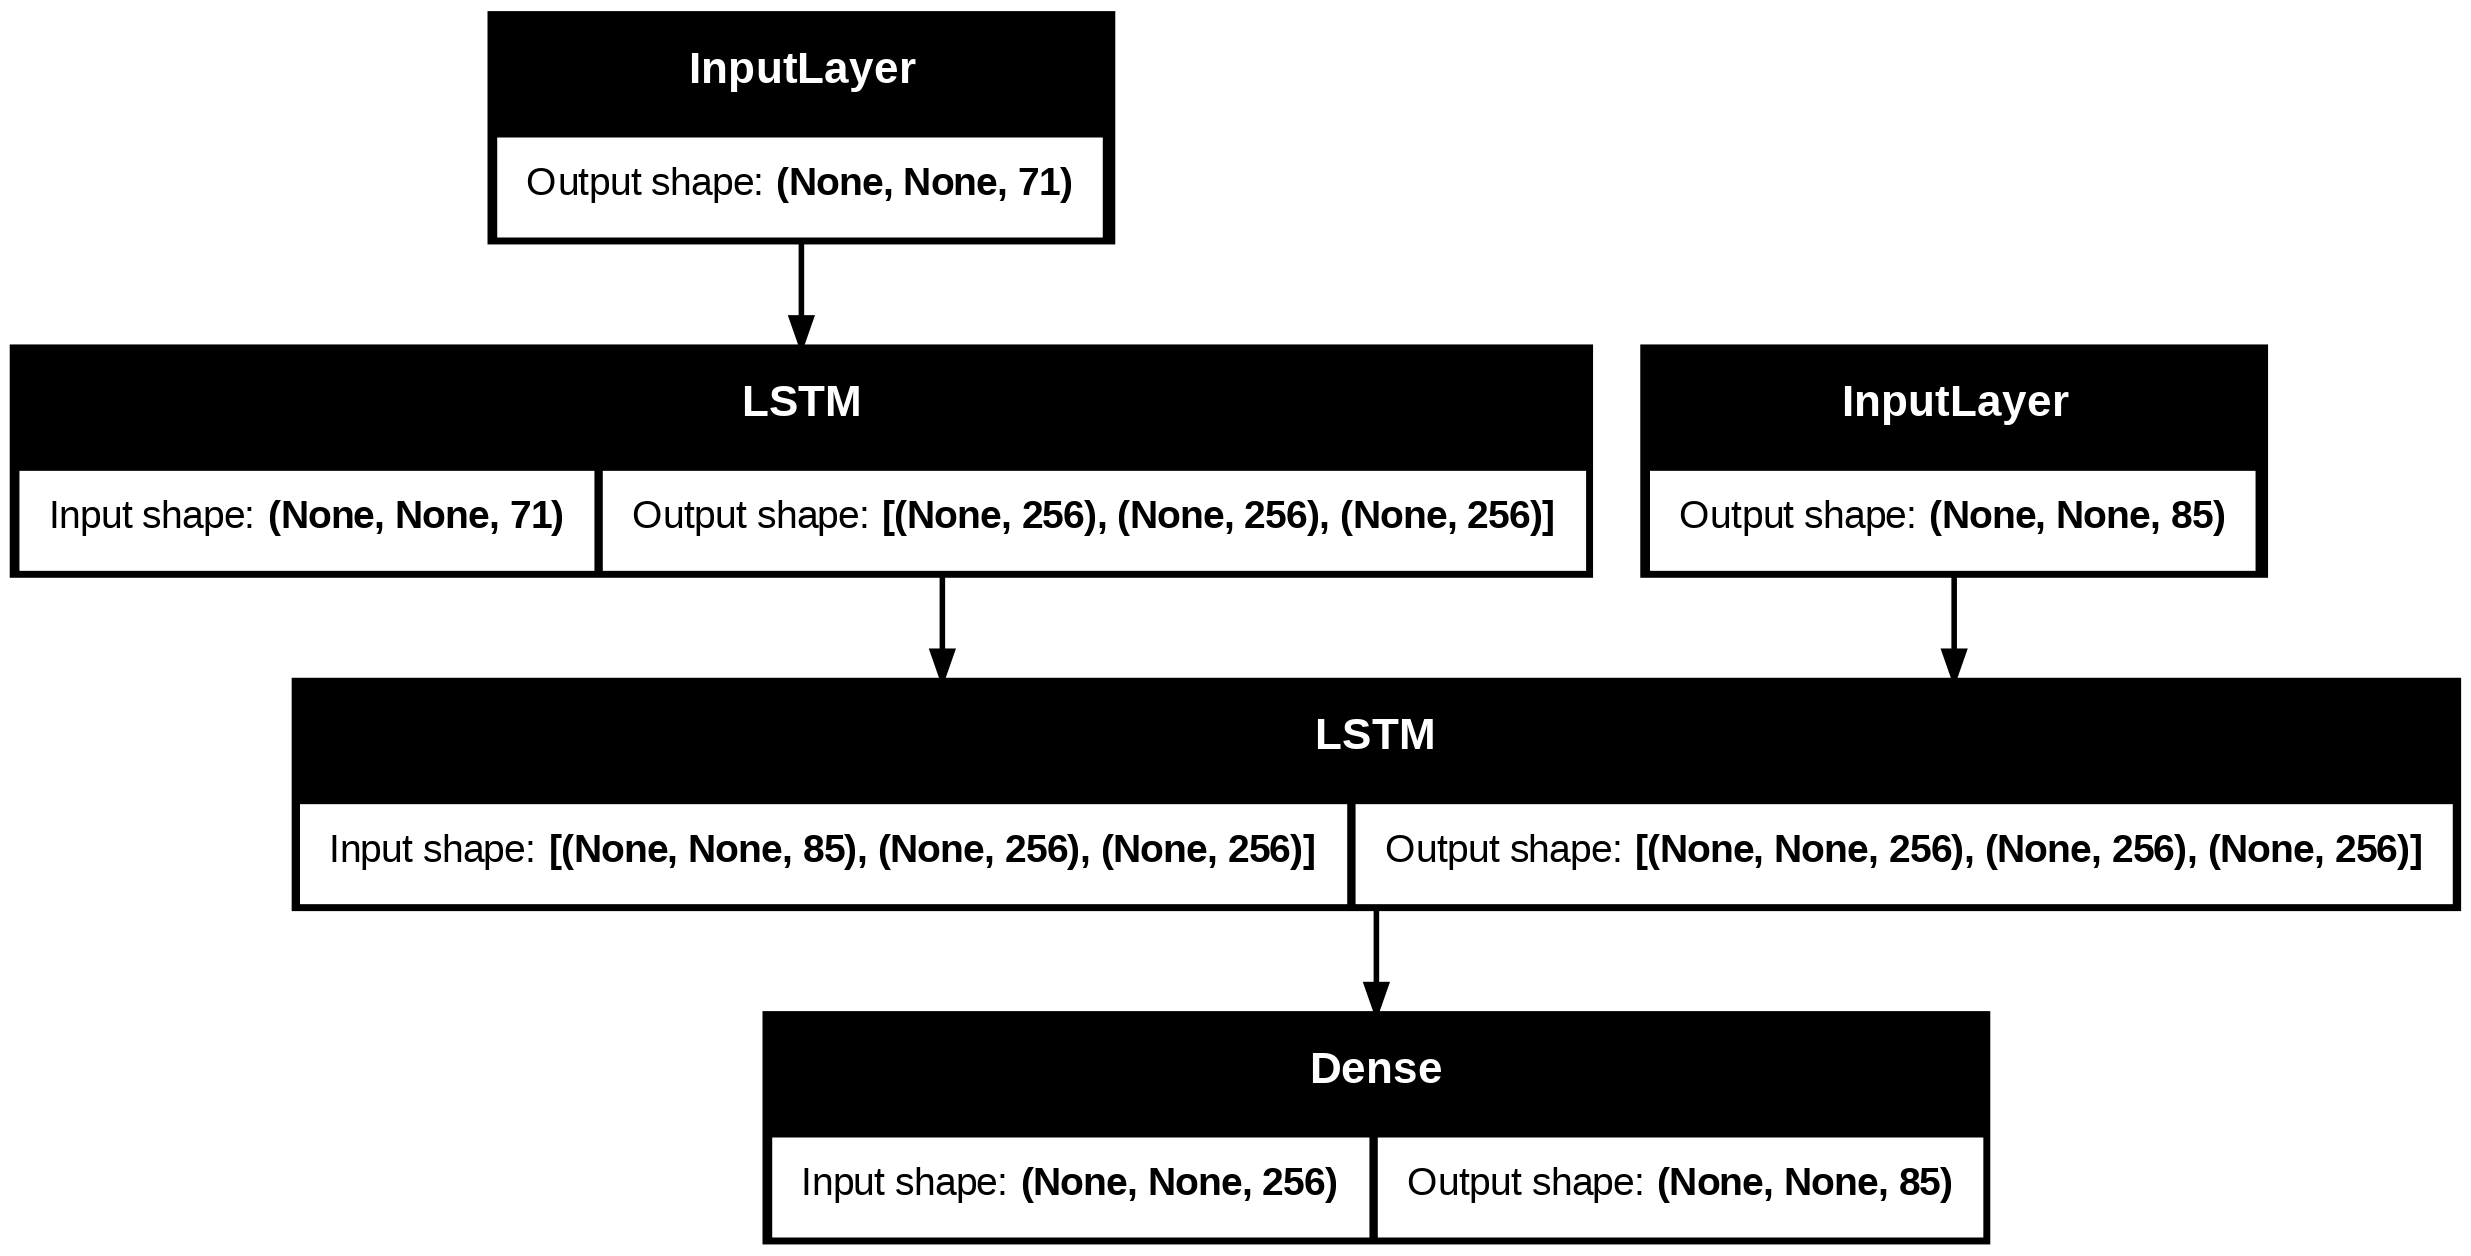

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model.layers

[<InputLayer name=input_layer, built=True>,
 <InputLayer name=input_layer_1, built=True>,
 <LSTM name=lstm, built=True>,
 <LSTM name=lstm_1, built=True>,
 <Dense name=dense, built=True>]

In [ ]:
model.input

[<KerasTensor shape=(None, None, 71), dtype=float32, sparse=False, ragged=False, name=keras_tensor>,
 <KerasTensor shape=(None, None, 85), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4>]

### Create the Inference Model

In [ ]:
def build_inference_model(model, latent_dim, num_decoder_tokens, target_token_index):
    # Load the saved model to ensure we use the best trained weights
    model = keras.models.load_model(MODEL_PATH)

    # Set up the encoder model — takes English input, returns context states
    encoder_inputs = model.input[0] # input_1
    encoder_outputs, state_h_enc, state_c_enc = model.layers[2].output  # lstm_1
    encoder_states = [state_h_enc, state_c_enc]
    encoder_model = keras.Model(encoder_inputs, encoder_states)

    # Set up the decoder model — takes one German character + states, returns next character + states
    decoder_inputs = model.input[1] # input_2
    # Define inputs for the hidden states
    decoder_state_input_h = keras.Input(shape=(latent_dim,), name='input_3')
    decoder_state_input_c = keras.Input(shape=(latent_dim,), name='input_4')
    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
    decoder_lstm = model.layers[3]
    decoder_outputs, state_h_dec, state_c_dec = decoder_lstm(
        decoder_inputs, initial_state=decoder_states_inputs
    )
    decoder_states = [state_h_dec, state_c_dec]
    decoder_dense = model.layers[4]
    decoder_outputs = decoder_dense(decoder_outputs)

    # The decoder model takes the previous character and states as input
    # and returns the next character prediction and updated states
    decoder_model = keras.Model(
        [decoder_inputs] + decoder_states_inputs,
        [decoder_outputs] + decoder_states
    )

    # Build reverse index dictionaries to convert indices back to characters
    reverse_input_char_index  = dict((i, char) for char, i in input_token_index.items())
    reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

    return encoder_model, decoder_model, reverse_input_char_index, reverse_target_char_index

In [ ]:
encoder_model, decoder_model, reverse_input_char_index, reverse_target_char_index = \
    build_inference_model(model, LATENT_DIM, num_decoder_tokens, target_token_index)

### Decode Sequence

In [ ]:
def decode_sequence(input_seq):
    # Encode the input English sentence as context state vectors
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Generate an empty target sequence of length 1 — start with the \t token
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    # Populate the first character with the start character \t
    target_seq[0, 0, target_token_index['\t']] = 1.0

    # Sampling loop — generates one German character per iteration
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        # Forecast the next character and updated hidden states
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value, verbose=0
        )
        # Get the index of the most likely character
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        # Map the index back to the actual German character
        sampled_char = reverse_target_char_index[sampled_token_index]
        # Add the predicted character to the output sentence
        decoded_sentence += sampled_char

        # Stop when we predict the end character \n or exceed the max length
        if sampled_char == '\n' or len(decoded_sentence) > max_decoder_seq_length:
            stop_condition = True

        # Update the target sequence with the predicted character for the next step
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1.0

        # Update the hidden states with the context from the current step
        states_value = [h, c]

    return decoded_sentence

In [ ]:
for seq_index in range(10):
    # Take one sequence (part of the training set) for trying out decoding
    input_seq = encoder_input_data[seq_index: seq_index + 1]
    decoded_sentence = decode_sequence(input_seq)
    print('-')
    print('Input sentence:', input_texts[seq_index])
    print('Decoded sentence:', decoded_sentence)

-
Input sentence: Go.
Decoded sentence: Geh es mir.

-
Input sentence: Hi.
Decoded sentence: Wie komm das herein.

-
Input sentence: Hi.
Decoded sentence: Wie komm das herein.

-
Input sentence: Run!
Decoded sentence: Mach es noch mal.

-
Input sentence: Run.
Decoded sentence: Halte dich nicht!

-
Input sentence: Wow!
Decoded sentence: Was geht mir gesehen?

-
Input sentence: Wow!
Decoded sentence: Was geht mir gesehen?

-
Input sentence: Fire!
Decoded sentence: Bist du einen Nehen?

-
Input sentence: Help!
Decoded sentence: Half ich das machen!

-
Input sentence: Help!
Decoded sentence: Half ich das machen!



### Forecast on New English Input

In [ ]:
def translate_new_input(new_input_text, input_token_index,
                         max_encoder_seq_length, num_encoder_tokens):
    # Create a one-hot matrix for the new input sentence
    new_encoder_input = np.zeros(
        (1, max_encoder_seq_length, num_encoder_tokens), dtype='float32'
    )
    # Fill in the one-hot values for each character in the new sentence
    for t, char in enumerate(new_input_text):
        new_encoder_input[0, t, input_token_index[char]] = 1.0
    # Pad remaining positions with the space character
    new_encoder_input[0, t + 1:, input_token_index[' ']] = 1.0
    return new_encoder_input

In [ ]:
# Test with a simple English phrase
new_input_text = 'Hello'
new_encoder_input = translate_new_input(
    new_input_text, input_token_index,
    max_encoder_seq_length, num_encoder_tokens
)
decoded_sentence = decode_sequence(new_encoder_input)
print(f'The input sentence: {new_input_text}, the decoded sentence: = {decoded_sentence}')

# Try a few more phrases
for phrase in ['Go.', 'Help!', 'Wait.', 'Thank you.']:
    new_encoder_input = translate_new_input(
        phrase, input_token_index,
        max_encoder_seq_length, num_encoder_tokens
    )
    decoded_sentence = decode_sequence(new_encoder_input)
    print(f'The input sentence: {phrase}, the decoded sentence: = {decoded_sentence}')

The input sentence: Hello, the decoded sentence: = Bleib nicht stehen.

The input sentence: Go., the decoded sentence: = Schreien Sie nicht auf.

The input sentence: Help!, the decoded sentence: = Bleib nicht stehen.

The input sentence: Wait., the decoded sentence: = Alle auf!

The input sentence: Thank you., the decoded sentence: = Es ist nicht heiß.

